In [26]:
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from fmri_mapping.embedding.evaluation import accuracy_cosine_similarity, compute_rsa


embeddings_folder = "../assets/embeddings_standarized/avg_ws_mlp_v1_128_768_sub-{subject:02d}.pt"
alignments_folder = Path("../assets/alignments/")


In [13]:
def load_subject_embeddings_test(subject):
    embedding_path = embeddings_folder.format(subject=subject)
    pck = torch.load(embedding_path)
    Z_test = pck["Z_test"]
    # Restrict to those common to all
    Z_test = Z_test[:515, :]
    labels_test = pck["labels_test"][:515]

    return Z_test, labels_test, pck["Z_test"]

# Evaluate pairwise alignments

In [32]:
pcks = list(alignments_folder.glob("**/*.pt"))

subject_x, subject_y = 1, 2

results = []
matrices = {}
mean_matrix_scores = []
mean_matrices = {}

all_rotations = []
for subject_x in range(1, 9):
    for subject_y in range(1, 9):
        if subject_x == subject_y:
            continue
        Z_test_x, labels_test_x, Z_test_x_full = load_subject_embeddings_test(subject_x)
        Z_test_y, labels_test_y, Z_test_y_full = load_subject_embeddings_test(subject_y)

        assert (labels_test_x == labels_test_y).all(), "Test labels should be the same for both subjects"

        # Filter those with the part "sub-{subject_x:02d}-sub-{subject_y:02d}" in the name
        pcks_x_y = [pck for pck in pcks if f"sub-{subject_x:02d}-sub-{subject_y:02d}" in pck.name]
        # Same for pcks_y_x 
        pcks_y_x = [pck for pck in pcks if f"sub-{subject_y:02d}-sub-{subject_x:02d}" in pck.name]

        Ws_x_y = [d["W"] for d in map(torch.load, pcks_x_y) if not torch.isnan(d["W"]).any()]
        #Ws_y_x = [d["W"] for d in map(torch.load, pcks_y_x) if not torch.isnan(d["W"]).any()]
        candidates = Ws_x_y

        # Add the pcks_y_x transposed as well to the list of candidates
        candidates += [d["W"].T for d in map(torch.load, pcks_y_x) if not torch.isnan(d["W"].T).any()]
        mean_matrix = torch.stack(candidates).mean(dim=0)
        # Reproject to O(d) using SVD
        #U, S, Vt = torch.linalg.svd(mean_matrix)
        #mean_matrix = U @ Vt

        acc, cos, mr = accuracy_cosine_similarity(Z_test_x @ mean_matrix, Z_test_y)
        mean_matrix_scores.append({"subject_x": subject_x, "subject_y": subject_y, "accuracy": acc, "cosine_similarity": cos, "mean_rank": mr})
        mean_matrices[(subject_x, subject_y)] = mean_matrix

        scores = []
        recalls = []
        for i, candidate_W in enumerate(candidates):
            acc, cos, mr = accuracy_cosine_similarity(Z_test_x @ candidate_W, Z_test_y)
            rsa = compute_rsa(Z_test_x @ candidate_W, Z_test_y) # RSA is invariant to rotation, so not need to compute it for different seeds
            scores.append(mr)
            recalls.append(acc)
            all_rotations.append({"subject_x": subject_x, "subject_y": subject_y, "run": i, "accuracy": acc, "cosine_similarity": cos, "mean_rank": mr, "rsa": rsa})
            
        candidate_W = candidates[np.argmin(scores)]

        # Best mean rank
        optimal_mean_rank = np.min(scores)
        optimal_recall = np.max(recalls)

        mean_mean_rank = np.mean(scores)
        mean_recall = np.mean(recalls)

        median_mean_rank = np.median(scores)
        median_recall = np.median(recalls)

        std_mean_rank = np.std(scores)
        std_recall = np.std(recalls)

        rsa = all_rotations[-1]["rsa"] # Same for all rotations, so we can just take the last one computed


        matrices[(subject_x, subject_y)] = candidate_W
        accuracy, cosine, mean_rank = accuracy_cosine_similarity(Z_test_x @ candidate_W, Z_test_y)
        results.append({
            "subject_x": subject_x,
            "subject_y": subject_y,
            "accuracy": accuracy,
            "cosine_similarity": cosine,
            "mean_rank": mean_rank,
            "optimal_mean_rank": optimal_mean_rank,
            "optimal_recall": optimal_recall,
            "mean_mean_rank": mean_mean_rank,
            "mean_recall": mean_recall,
            "median_mean_rank": median_mean_rank,
            "median_recall": median_recall,
            "std_mean_rank": std_mean_rank,
            "std_recall": std_recall,
            "rsa": rsa
        })
        #print(subject_x, subject_y, f"Candidate W: Accuracy: {accuracy}, Cosine similarity: {cosine}, Mean rank: {mean_rank}")

df = pd.DataFrame(results)
df_detailed = pd.DataFrame(all_rotations)
df_mean_matrix = pd.DataFrame(mean_matrix_scores)

## Figure S3. 


For each ordered subject pair, we ran the unsupervised pairwise brain-to-brain translation procedure with 10 different random seeds and evaluated Mean Rank on the cross-subject retrieval task using the 515 held-out shared images. Left: Mean Rank for the best-performing seed for each pair, corresponding to the protocol used in the main results (average $\pm$ std: $2.56 \pm 1.71$). Middle: Mean Rank after averaging the 10 rotation matrices for each pair and projecting the result back onto $\mathcal{O}(d)$, using all runs without seed selection (average $\pm$ std: $4.61 \pm 4.37$). Right: distribution of Mean Rank values across all candidate rotations and subject pairs ($10$ seeds $\times$ $56$ ordered pairs). Lower is better; darker colors in the heatmaps indicate better retrieval.

Best matrix stats.  mean=2.56 std=1.71
Mean matrix stats.  mean=4.61 std=4.37


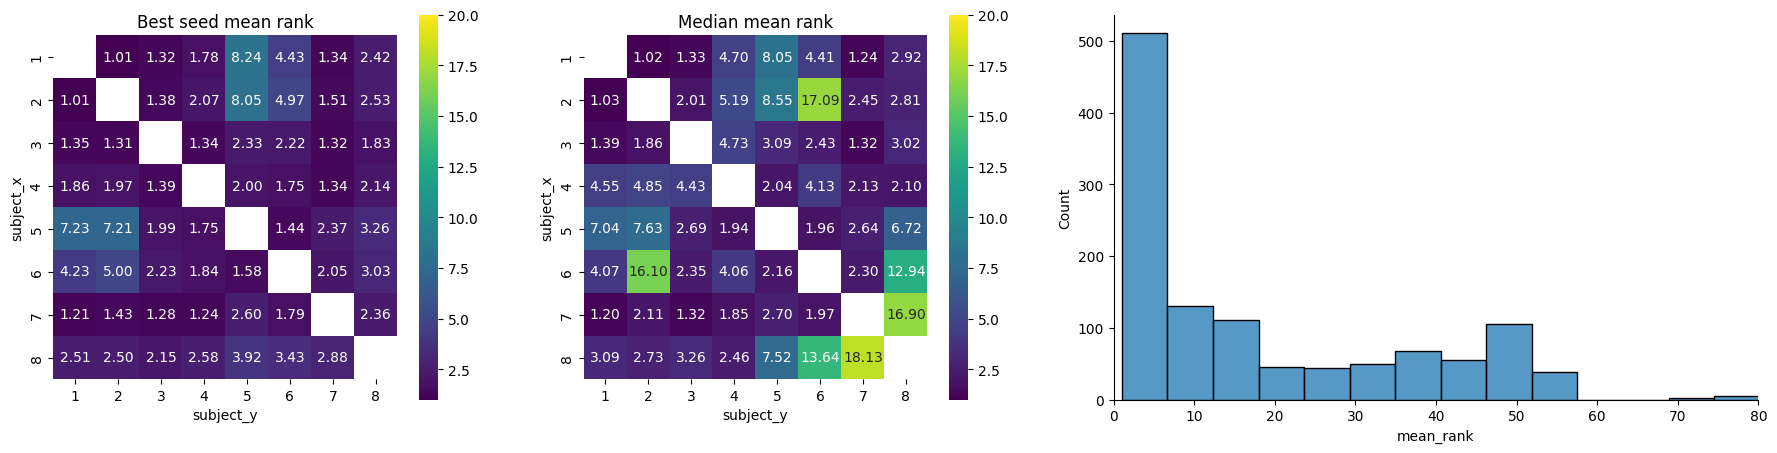

In [25]:
# Make a mean rank matrix with mean mean ranks optimal and median

vmin, vmax = 1, 20
cmap = "viridis"
fig, axes = plt.subplots(1, 3, figsize=(22, 5), gridspec_kw={"width_ratios": [1, 1, 1.5]})
sns.heatmap(df.pivot(index="subject_x", columns="subject_y", values="optimal_mean_rank"), ax=axes[0], annot=True, fmt=".2f", cmap=cmap, square=True, vmin=vmin, vmax=vmax)
sns.heatmap(df_mean_matrix.pivot(index="subject_x", columns="subject_y", values="mean_rank"), ax=axes[1], annot=True, fmt=".2f", cmap=cmap,  square=True, vmin=vmin, vmax=vmax)

sns.histplot(df_detailed, x="mean_rank",  ax=axes[2], stat="count")

axes[0].set_title("Best seed mean rank")
axes[1].set_title("Median mean rank")
axes[2].set_xlim(0, 80)
sns.despine(ax=axes[2])


print(f"Best matrix stats.  mean={df["mean_rank"].mean().round(2)} std={df["mean_rank"].std().round(2)}")
print(f"Mean matrix stats.  mean={df_mean_matrix["mean_rank"].mean().round(2)} std={df_mean_matrix["mean_rank"].std().round(2)}")


Pairwise alignments main

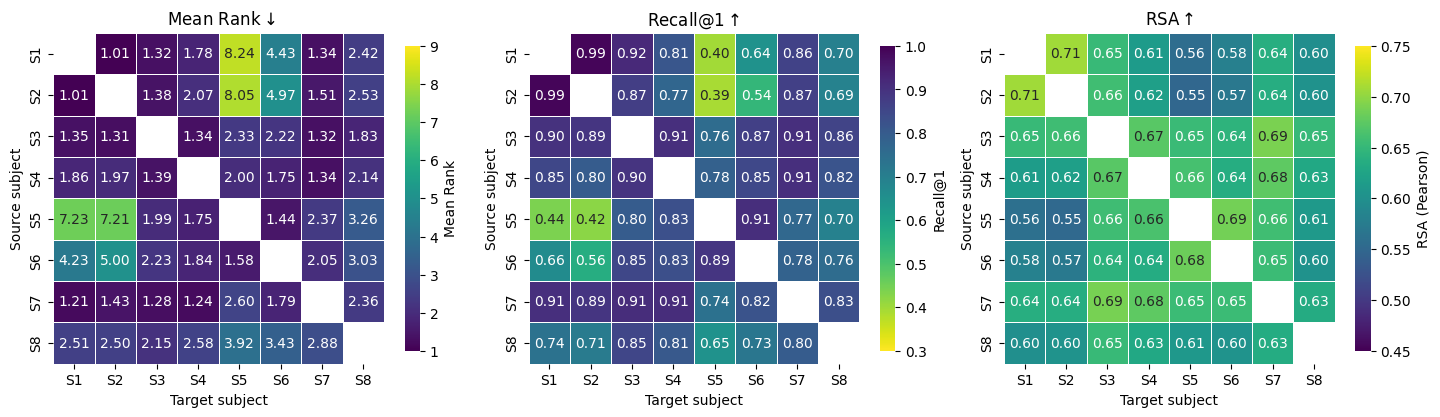

In [40]:
rsa = rsa = df.pivot(columns="subject_y", index="subject_x", values="rsa").values



s = 1.1
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(s*16, s*6))
df_pivot = df.pivot(columns="subject_y", index="subject_x", values="mean_rank")
ticks = [f"S{i}" for i in range(1, 9)]
cmap = "viridis"
cmap2 = "viridis_r"
cmap3 = "viridis"
#df_pivot = df_pivot.fillna(1)

sns.heatmap(data=df_pivot, cmap=cmap, ax=ax1, linewidths=0.5, annot=True, fmt=".2f", square=True, vmin=1, vmax=9, cbar_kws={"label": "Mean Rank", "shrink":0.6},
            xticklabels=ticks, yticklabels=ticks)
ax1.set_ylabel("Source subject")
ax1.set_xlabel("Target subject")
ax1.set_title(r" Mean Rank$\downarrow$")


df_pivot = df.pivot(columns="subject_y", index="subject_x", values="accuracy")
# df_pivot = df_pivot.fillna(1)
sns.heatmap(data=df_pivot, cmap=cmap2, ax=ax2, linewidths=0.5, annot=True, fmt=".2f", square=True, vmin=0.3, vmax=1, cbar_kws={"label": "Recall@1", "shrink":0.6},
            xticklabels=ticks, yticklabels=ticks)
ax2.set_ylabel("Source subject")
ax2.set_xlabel("Target subject")
ax2.set_title(r"Recall@1$\uparrow$")


sns.heatmap(data=rsa, cmap=cmap3, ax=ax3, linewidths=0.5, annot=True, fmt=".2f", square=True, vmin=0.45, vmax=0.75, cbar_kws={"label": r"RSA (Pearson)", "shrink":0.6},
            xticklabels=ticks, yticklabels=ticks)
ax3.set_ylabel("Source subject")
ax3.set_xlabel("Target subject")
ax3.set_title(r"RSA$\uparrow$")

# Reduce spacing between subplots
plt.subplots_adjust(wspace=0.15)

fig.savefig("pairwise_alignment_results.pdf", bbox_inches="tight", transparent=True)

In [45]:
print(f"mean_rank: {df.mean_rank.mean():.2f} ± {df.mean_rank.std():.2f}")
print(f"R@1: {df.accuracy.mean():.2f} ± {df.accuracy.std():.2f}")
print(f"RSA: {df.rsa.mean():.2f} ± {df.rsa.std():.2f}")

mean_rank: 2.56 ± 1.71
R@1: 0.78 ± 0.14
RSA: 0.63 ± 0.04


# Global alignment

In [48]:
# Simetrize the matrices
results_simetrized = []
matrices_simetrized = {}
for (subject_x, subject_y) in matrices.keys():
    W_x = matrices[(subject_x, subject_y)]
    W_y = matrices[(subject_y, subject_x)]
    W = (W_x + W_y.T) / 2
    # Reproject to O(d) using SVD
    #U, S, Vt = torch.linalg.svd(W)
    #W = U @ Vt
    matrices_simetrized[(subject_x, subject_y)] = W

for subject_x in range(1, 9):
    for subject_y in range(1, 9):
        if subject_x == subject_y:
            continue
        Z_test_x, labels_test_x, Z_test_x_full = load_subject_embeddings_test(subject_x)
        Z_test_y, labels_test_y, Z_test_y_full = load_subject_embeddings_test(subject_y)
        candidate_W = matrices_simetrized[(subject_x, subject_y)]
        accuracy, cosine, mean_rank = accuracy_cosine_similarity(Z_test_x @ candidate_W, Z_test_y)
        results_simetrized.append({
            "subject_x": subject_x,
            "subject_y": subject_y,
            "accuracy": accuracy,
            "cosine_similarity": cosine,
            "mean_rank": mean_rank
        })

df_simetrized = pd.DataFrame(results_simetrized)

print(f"Simetrized mean rank: {df_simetrized.mean_rank.mean().round(2)}, {df_simetrized.mean_rank.std().round(2)}")

Simetrized mean rank: 2.54, 1.72


Global syncronization

In [49]:
N = 8
d = 128
# Assume `W_ij_dict` is a dictionary where keys are (i, j) tuples 
# and values are your 128x128 orthonormal tensors.

W_global = torch.zeros((N * d, N * d))

for i in range(N):
    for j in range(N):
        row_start, row_end = i * d, (i + 1) * d
        col_start, col_end = j * d, (j + 1) * d
        
        if i == j:
            W_global[row_start:row_end, col_start:col_end] = torch.eye(d)
        else:
            W_global[row_start:row_end, col_start:col_end] = matrices_simetrized[(i+1, j+1)]

# Spectral Initialization
# torch.linalg.eigh is optimized for symmetric/Hermitian matrices.
# Ensure your W_global is symmetric (W_ji = W_ij^T) before doing this!
eigenvalues, eigenvectors = torch.linalg.eigh(W_global)

# eigh returns eigenvalues in ascending order, so we take the last 'd' columns
U = eigenvectors[:, -d:]

# Project the relaxed blocks back onto the orthogonal manifold
R_init = []
R_init_not_orthogonal = []
for i in range(N):
    U_i = U[i * d : (i + 1) * d, :]
    R_init_not_orthogonal.append(U_i)
    # Reproject the final U_i onto the closest orthogonal matrix using SVD
    u, s, vh = torch.linalg.svd(U_i)
    R_i = u @ vh  # This ensures R_i is strictly orthonormal
    R_init.append(R_i)

In [50]:
# Load Z tests
Z_tests = []
for subject_x in range(1, 9):
    Z_test_x, labels_test_x, Z_test_x_full = load_subject_embeddings_test(subject_x)
    Z_tests.append(Z_test_x)


results_global = []
for subject_x in range(1, 9):
    for subject_y in range(1, 9):
        if subject_x == subject_y:
            continue
        Z_test_x = Z_tests[subject_x - 1]
        Z_test_y = Z_tests[subject_y - 1]
        candidate_W = R_init[subject_x - 1] @ R_init[subject_y - 1].T
        accuracy, cosine, mean_rank = accuracy_cosine_similarity(Z_test_x @ candidate_W, Z_test_y)
        results_global.append({
            "subject_x": subject_x,
            "subject_y": subject_y,
            "accuracy": accuracy,
            "cosine_similarity": cosine,
            "mean_rank": mean_rank
        })

df_global = pd.DataFrame(results_global)


print(f"Global alignment mean rank: {df_global.mean_rank.mean().round(2)}, {df_global.mean_rank.std().round(2)}")
# recall
print(f"Global alignment recall@1: {df_global.accuracy.mean().round(2)} ± {df_global.accuracy.std().round(2)}")

Global alignment mean rank: 2.0, 0.76
Global alignment recall@1: 0.83 ± 0.09


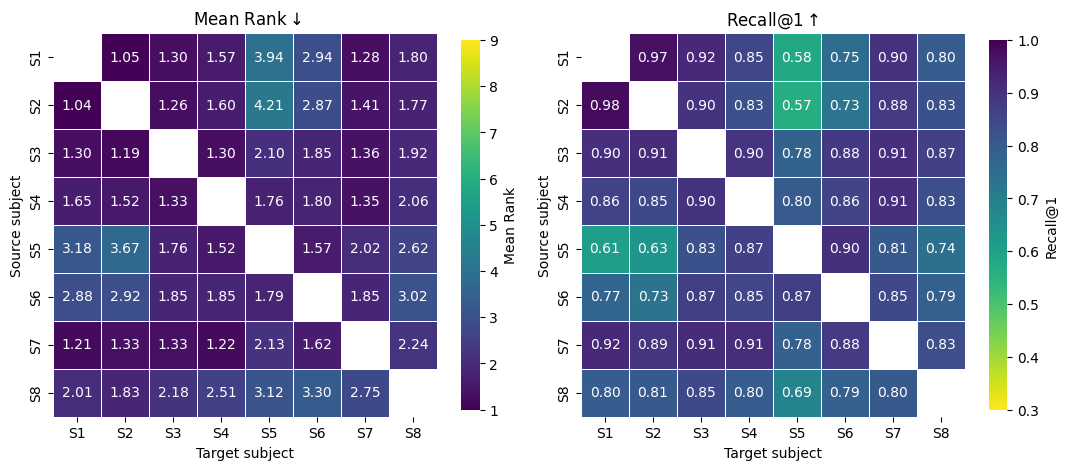

In [53]:

cmap = "viridis"
cmap2 = "viridis_r"
# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
df_pivot = df_global.pivot(columns="subject_y", index="subject_x", values="mean_rank")



sns.heatmap(data=df_pivot, cmap=cmap, ax=ax1, linewidths=0.5, annot=True, fmt=".2f", square=True, vmin=1, vmax=9, cbar_kws={"label": "Mean Rank", "shrink":0.8},
            xticklabels=ticks, yticklabels=ticks)
ax1.set_ylabel("Source subject")
ax1.set_xlabel("Target subject")
ax1.set_title(r" Mean Rank$\downarrow$")

df_pivot = df_global.pivot(columns="subject_y", index="subject_x", values="accuracy")

sns.heatmap(data=df_pivot, cmap=cmap2, ax=ax2, linewidths=0.5, annot=True, fmt=".2f", square=True, vmin=0.3, vmax=1, cbar_kws={"label": "Recall@1", "shrink":0.8},
            xticklabels=ticks, yticklabels=ticks)
ax2.set_ylabel("Source subject")
ax2.set_xlabel("Target subject")
ax2.set_title(r"Recall@1$\uparrow$")
# Space between subplots
fig.subplots_adjust(wspace=0.1)
fig.savefig("pairwise_alignment_global_results.pdf", bbox_inches="tight", transparent=True)